## 1. Import Library dan Load Dataset

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

# Upload file dataset_kelulusan_mahasiswa.csv ke Colab (jalankan sel ini lalu pilih file)
try:
    from google.colab import files
    uploaded = files.upload()
except ImportError:
    pass  # jika dijalankan lokal, pastikan file ada di folder yang sama

df = pd.read_csv("dataset_kelulusan_mahasiswa.csv")
df_raw = df.copy()   # salinan data asli untuk perbandingan di akhir
df.head()

Saving dataset_kelulusan_mahasiswa.csv to dataset_kelulusan_mahasiswa.csv


,id_mahasiswa,jenis_kelamin,jurusan,semester,ipk,kehadiran_persen,jam_belajar_per_minggu,tugas_terkumpul,nilai_uts,nilai_uas,aktif_organisasi,kerja_paruh_waktu,status_kelulusan
0,MHS0001,Perempuan,Teknik Industri,8,2.22,50.2,6.9,5,57,64,Tidak,Tidak,Terlambat
1,MHS0002,Laki-laki,Teknik Sipil,2,3.06,65.5,12.6,9,69,71,Tidak,Tidak,Tepat Waktu
2,MHS0003,Perempuan,Teknik Sipil,4,2.68,60.3,9.1,8,54,63,Ya,Tidak,Terlambat
3,MHS0004,Perempuan,Teknik Elektro,5,2.48,55.0,9.4,8,33,58,Ya,Ya,Terlambat
4,MHS0005,Laki-laki,Teknik Elektro,7,2.69,67.7,15.0,8,50,53,Ya,Tidak,Terlambat


## 2. Pemahaman Dataset
Dataset berisi data akademik dan aktivitas mahasiswa beserta status kelulusannya. Kolom yang ada:

| Kolom | Keterangan |
|---|---|
| id_mahasiswa | ID unik mahasiswa |
| jenis_kelamin, jurusan, semester | Data demografis dan akademik |
| ipk | Indeks prestasi kumulatif (0-4) |
| kehadiran_persen | Persentase kehadiran kuliah (0-100) |
| jam_belajar_per_minggu | Rata-rata jam belajar mandiri per minggu |
| tugas_terkumpul | Jumlah tugas yang dikumpulkan |
| nilai_uts, nilai_uas | Nilai ujian (0-100) |
| aktif_organisasi, kerja_paruh_waktu | Aktivitas di luar kuliah (Ya/Tidak) |
| status_kelulusan | Target: Tepat Waktu / Terlambat |

In [5]:
print("Jumlah baris dan kolom:", df.shape)
df.info()

Jumlah baris dan kolom: (500, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_mahasiswa            500 non-null    object 
 1   jenis_kelamin           500 non-null    object 
 2   jurusan                 500 non-null    object 
 3   semester                500 non-null    int64  
 4   ipk                     490 non-null    float64
 5   kehadiran_persen        488 non-null    float64
 6   jam_belajar_per_minggu  485 non-null    float64
 7   tugas_terkumpul         500 non-null    int64  
 8   nilai_uts               500 non-null    int64  
 9   nilai_uas               500 non-null    int64  
 10  aktif_organisasi        500 non-null    object 
 11  kerja_paruh_waktu       500 non-null    object 
 12  status_kelulusan        500 non-null    object 
dtypes: float64(3), int64(4), object(6)
memory usage: 50.9+ KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
semester,500.0,4.950000,1.960405,2.00,3.00,5.00,7.00,8.0
ipk,490.0,3.060816,0.328562,2.19,2.85,3.08,3.29,4.0
kehadiran_persen,488.0,80.785656,12.056343,46.50,73.30,81.70,89.40,100.0
jam_belajar_per_minggu,485.0,11.675052,4.764948,1.00,8.30,12.00,14.90,26.3
tugas_terkumpul,500.0,11.222000,2.135846,5.00,10.00,12.00,13.00,14.0
nilai_uts,500.0,70.744000,12.648258,32.00,63.00,71.00,79.00,100.0
nilai_uas,500.0,71.390000,12.753321,26.00,63.00,71.00,80.00,100.0


In [7]:
print("Distribusi status kelulusan:")
print(df["status_kelulusan"].value_counts())
print()
print("Jumlah mahasiswa per jurusan:")
print(df["jurusan"].value_counts())

Distribusi status kelulusan:
status_kelulusan
Tepat Waktu    359
Terlambat      141
Name: count, dtype: int64

Jumlah mahasiswa per jurusan:
jurusan
Informatika         155
Sistem Informasi     99
Teknik Elektro       87
Teknik Sipil         85
Teknik Industri      74
Name: count, dtype: int64


## 3. Identifikasi Masalah Kualitas Data

### 3.1 Missing Values

In [23]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"jumlah_missing": missing, "persen": missing_pct})[missing > 0]

,jumlah_missing,persen


### 3.2 Data Duplikat dan Inkonsistensi Format

In [24]:
print("Baris duplikat penuh      :", df.duplicated().sum())
print("ID mahasiswa duplikat     :", df["id_mahasiswa"].duplicated().sum())

# cek spasi berlebih dan variasi penulisan pada kolom kategorikal
kolom_kat = ["jenis_kelamin", "jurusan", "aktif_organisasi", "kerja_paruh_waktu", "status_kelulusan"]
for c in kolom_kat:
    spasi = (df[c] != df[c].str.strip()).sum()
    print(f"{c:20s} | nilai unik: {sorted(df[c].unique())} | spasi berlebih: {spasi}")

Baris duplikat penuh      : 0
ID mahasiswa duplikat     : 0
jenis_kelamin        | nilai unik: ['Laki-laki', 'Perempuan'] | spasi berlebih: 0
jurusan              | nilai unik: ['Informatika', 'Sistem Informasi', 'Teknik Elektro', 'Teknik Industri', 'Teknik Sipil'] | spasi berlebih: 0
aktif_organisasi     | nilai unik: ['Tidak', 'Ya'] | spasi berlebih: 0
kerja_paruh_waktu    | nilai unik: ['Tidak', 'Ya'] | spasi berlebih: 0
status_kelulusan     | nilai unik: ['Tepat Waktu', 'Terlambat'] | spasi berlebih: 0


### 3.3 Validasi Rentang Nilai (Data Tidak Valid)

In [25]:
aturan = {
    "ipk": (0, 4),
    "kehadiran_persen": (0, 100),
    "jam_belajar_per_minggu": (0, 168),
    "nilai_uts": (0, 100),
    "nilai_uas": (0, 100),
    "semester": (1, 14),
}
for kolom, (lo, hi) in aturan.items():
    tidak_valid = ((df[kolom] < lo) | (df[kolom] > hi)).sum()
    print(f"{kolom:25s} rentang valid {lo}-{hi} | data di luar rentang: {tidak_valid}")

ipk                       rentang valid 0-4 | data di luar rentang: 0
kehadiran_persen          rentang valid 0-100 | data di luar rentang: 0
jam_belajar_per_minggu    rentang valid 0-168 | data di luar rentang: 0
nilai_uts                 rentang valid 0-100 | data di luar rentang: 0
nilai_uas                 rentang valid 0-100 | data di luar rentang: 0
semester                  rentang valid 1-14 | data di luar rentang: 0


### 3.4 Outlier (Metode IQR)

In [26]:
kolom_num = ["ipk", "kehadiran_persen", "jam_belajar_per_minggu", "tugas_terkumpul", "nilai_uts", "nilai_uas"]
hasil = []
for c in kolom_num:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    batas_bawah, batas_atas = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[c] < batas_bawah) | (df[c] > batas_atas)).sum()
    hasil.append([c, round(batas_bawah, 2), round(batas_atas, 2), n_out])
pd.DataFrame(hasil, columns=["kolom", "batas_bawah", "batas_atas", "jumlah_outlier"])

,kolom,batas_bawah,batas_atas,jumlah_outlier
0,ipk,2.21,3.92,0
1,kehadiran_persen,49.82,112.43,0
2,jam_belajar_per_minggu,-0.95,24.25,0
3,tugas_terkumpul,5.50,17.50,2
4,nilai_uts,39.00,103.00,0
5,nilai_uas,37.50,105.50,0


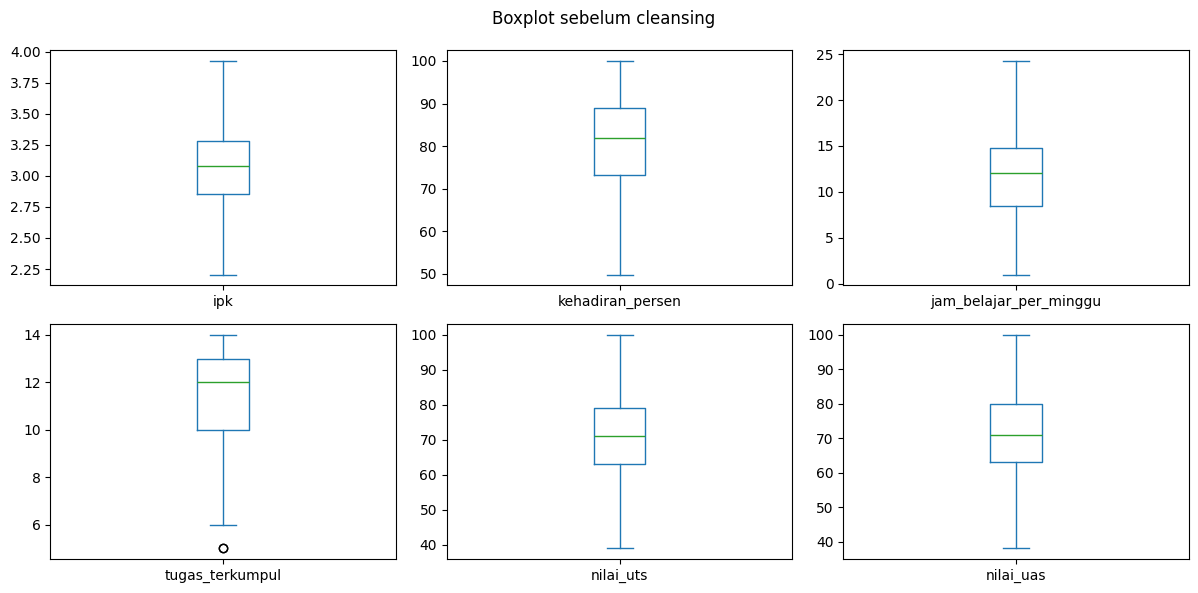

In [27]:
df[kolom_num].plot(kind="box", subplots=True, layout=(2, 3), figsize=(12, 6), title="Boxplot sebelum cleansing")
plt.tight_layout()
plt.show()

**Ringkasan temuan:**
- Missing values ada pada kolom `ipk`, `kehadiran_persen`, dan `jam_belajar_per_minggu`.
- Tidak ditemukan data duplikat, inkonsistensi penulisan kategori, maupun nilai di luar rentang valid.
- Terdapat beberapa outlier pada kolom numerik berdasarkan metode IQR.

## 4. Data Cleansing
### 4.1 Standardisasi Format
Walaupun tidak ditemukan inkonsistensi, standardisasi tetap dijalankan sebagai langkah pencegahan.

In [13]:
df.columns = df.columns.str.strip().str.lower()
for c in kolom_kat + ["id_mahasiswa"]:
    df[c] = df[c].str.strip()
df = df.drop_duplicates(subset="id_mahasiswa").reset_index(drop=True)
print("Jumlah baris setelah cek duplikat:", len(df))

Jumlah baris setelah cek duplikat: 500


### 4.2 Penanganan Missing Values
Nilai kosong diisi dengan **median per jurusan**. Median dipilih karena tidak terpengaruh outlier, dan pengelompokan per jurusan membuat nilai pengisi lebih sesuai dengan kondisi tiap jurusan. Pengisian sengaja tidak memakai `status_kelulusan` agar tidak terjadi kebocoran label (*data leakage*) pada tahap modeling nanti.

In [14]:
kolom_missing = ["ipk", "kehadiran_persen", "jam_belajar_per_minggu"]
for c in kolom_missing:
    df[c] = df[c].fillna(df.groupby("jurusan")[c].transform("median"))

print("Sisa missing values:")
print(df[kolom_missing].isnull().sum())

Sisa missing values:
ipk                       0
kehadiran_persen          0
jam_belajar_per_minggu    0
dtype: int64


### 4.3 Penanganan Outlier
Nilai ekstrem dibatasi dengan metode IQR (*capping/winsorizing*), bukan dihapus. Alasannya, nilai tersebut masih mungkin terjadi pada mahasiswa sungguhan, dan penghapusan akan mengurangi jumlah data. Untuk kolom yang punya batas logis (kehadiran dan nilai maksimal 100, jam belajar tidak negatif), batas IQR disesuaikan dengan batas tersebut.

In [15]:
batas_logis = {
    "ipk": (0, 4),
    "kehadiran_persen": (0, 100),
    "jam_belajar_per_minggu": (0, 168),
    "nilai_uts": (0, 100),
    "nilai_uas": (0, 100),
}
ringkasan = []
for c, (lo, hi) in batas_logis.items():
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    bawah = max(q1 - 1.5 * iqr, lo)
    atas = min(q3 + 1.5 * iqr, hi)
    n_diubah = ((df[c] < bawah) | (df[c] > atas)).sum()
    df[c] = df[c].clip(bawah, atas)
    ringkasan.append([c, round(bawah, 2), round(atas, 2), n_diubah])
pd.DataFrame(ringkasan, columns=["kolom", "batas_bawah", "batas_atas", "nilai_di-cap"])

,kolom,batas_bawah,batas_atas,nilai_di-cap
0,ipk,2.21,3.92,4
1,kehadiran_persen,49.82,100.00,4
2,jam_belajar_per_minggu,0.00,24.25,4
3,nilai_uts,39.00,100.00,5
4,nilai_uas,37.50,100.00,1


### 4.4 Perbaikan Tipe Data
Kolom `semester`, `tugas_terkumpul`, `nilai_uts`, dan `nilai_uas` dipastikan bertipe integer, sedangkan kolom kategorikal diubah ke tipe `category` agar lebih efisien.

In [16]:
df["semester"] = df["semester"].astype(int)
df["tugas_terkumpul"] = df["tugas_terkumpul"].astype(int)
df["nilai_uts"] = df["nilai_uts"].round().astype(int)
df["nilai_uas"] = df["nilai_uas"].round().astype(int)
for c in kolom_kat:
    df[c] = df[c].astype("category")
df.dtypes

,0
id_mahasiswa,object
jenis_kelamin,category
jurusan,category
semester,int64
ipk,float64
kehadiran_persen,float64
jam_belajar_per_minggu,float64
tugas_terkumpul,int64
nilai_uts,int64
nilai_uas,int64


## 5. Data Enrichment
Dataset ini belum memiliki fitur turunan yang menggambarkan performa dan perilaku mahasiswa secara ringkas. Karena tidak ada sumber data eksternal, enrichment dilakukan dengan membuat fitur baru dari kolom yang sudah ada.

In [17]:
# 1. Rata-rata nilai ujian
df["rata_nilai_ujian"] = ((df["nilai_uts"] + df["nilai_uas"]) / 2).round(1)

# 2. Selisih UAS terhadap UTS (positif = nilai membaik)
df["selisih_uas_uts"] = df["nilai_uas"] - df["nilai_uts"]

# 3. Kategori IPK
df["kategori_ipk"] = pd.cut(df["ipk"], bins=[0, 2.75, 3.5, 4.0],
                            labels=["Cukup", "Baik", "Sangat Baik"], include_lowest=True)

# 4. Kategori kehadiran
df["kategori_kehadiran"] = pd.cut(df["kehadiran_persen"], bins=[0, 75, 90, 100],
                                  labels=["Rendah", "Sedang", "Tinggi"], include_lowest=True)

# 5. Rasio pengumpulan tugas terhadap jumlah tugas maksimum pada data
df["rasio_tugas"] = (df["tugas_terkumpul"] / df["tugas_terkumpul"].max()).round(2)

# 6. Jumlah aktivitas di luar kuliah (organisasi + kerja paruh waktu)
df["jumlah_aktivitas_luar"] = (df["aktif_organisasi"] == "Ya").astype(int) + (df["kerja_paruh_waktu"] == "Ya").astype(int)

# 7. Tingkat studi
df["tingkat_studi"] = pd.cut(df["semester"], bins=[0, 4, 8],
                             labels=["Awal (Sem 1-4)", "Akhir (Sem 5-8)"])

# 8. Encoding target untuk keperluan modeling (1 = Tepat Waktu)
df["target_tepat_waktu"] = (df["status_kelulusan"] == "Tepat Waktu").astype(int)

df[["id_mahasiswa", "rata_nilai_ujian", "selisih_uas_uts", "kategori_ipk", "kategori_kehadiran",
    "rasio_tugas", "jumlah_aktivitas_luar", "tingkat_studi", "target_tepat_waktu"]].head()

,id_mahasiswa,rata_nilai_ujian,selisih_uas_uts,kategori_ipk,kategori_kehadiran,rasio_tugas,jumlah_aktivitas_luar,tingkat_studi,target_tepat_waktu
0,MHS0001,60.5,7,Cukup,Rendah,0.36,0,Akhir (Sem 5-8),0
1,MHS0002,70.0,2,Baik,Rendah,0.64,0,Awal (Sem 1-4),1
2,MHS0003,58.5,9,Cukup,Rendah,0.57,1,Awal (Sem 1-4),0
3,MHS0004,48.5,19,Cukup,Rendah,0.57,2,Akhir (Sem 5-8),0
4,MHS0005,51.5,3,Cukup,Rendah,0.57,1,Akhir (Sem 5-8),0


Cek apakah fitur baru memberi informasi tambahan terhadap status kelulusan:

In [18]:
print("Persentase lulus tepat waktu per kategori IPK:")
print((df.groupby("kategori_ipk", observed=True)["target_tepat_waktu"].mean() * 100).round(1))
print()
print("Persentase lulus tepat waktu per kategori kehadiran:")
print((df.groupby("kategori_kehadiran", observed=True)["target_tepat_waktu"].mean() * 100).round(1))
print()
print("Persentase lulus tepat waktu per jumlah aktivitas luar kuliah:")
print((df.groupby("jumlah_aktivitas_luar")["target_tepat_waktu"].mean() * 100).round(1))

Persentase lulus tepat waktu per kategori IPK:
kategori_ipk
Cukup          10.1
Baik           84.0
Sangat Baik    97.3
Name: target_tepat_waktu, dtype: float64

Persentase lulus tepat waktu per kategori kehadiran:
kategori_kehadiran
Rendah    34.5
Sedang    82.0
Tinggi    99.1
Name: target_tepat_waktu, dtype: float64

Persentase lulus tepat waktu per jumlah aktivitas luar kuliah:
jumlah_aktivitas_luar
0    75.4
1    69.1
2    67.9
Name: target_tepat_waktu, dtype: float64


## 6. Perbandingan Sebelum dan Sesudah

In [19]:
perbandingan = pd.DataFrame({
    "Sebelum": [df_raw.shape[0], df_raw.shape[1], df_raw.isnull().sum().sum(), df_raw.duplicated().sum()],
    "Sesudah": [df.shape[0], df.shape[1], df.isnull().sum().sum(), df.duplicated().sum()],
}, index=["Jumlah baris", "Jumlah kolom", "Total missing value", "Baris duplikat"])
perbandingan

,Sebelum,Sesudah
Jumlah baris,500,500
Jumlah kolom,13,21
Total missing value,37,0
Baris duplikat,0,0


In [20]:
kolom_cek = ["ipk", "kehadiran_persen", "jam_belajar_per_minggu"]
pd.DataFrame({
    "mean_sebelum": df_raw[kolom_cek].mean().round(3),
    "mean_sesudah": df[kolom_cek].mean().round(3),
    "std_sebelum": df_raw[kolom_cek].std().round(3),
    "std_sesudah": df[kolom_cek].std().round(3),
})

,mean_sebelum,mean_sesudah,std_sebelum,std_sesudah
ipk,3.061,3.061,0.329,0.324
kehadiran_persen,80.786,80.842,12.056,11.873
jam_belajar_per_minggu,11.675,11.674,4.765,4.656


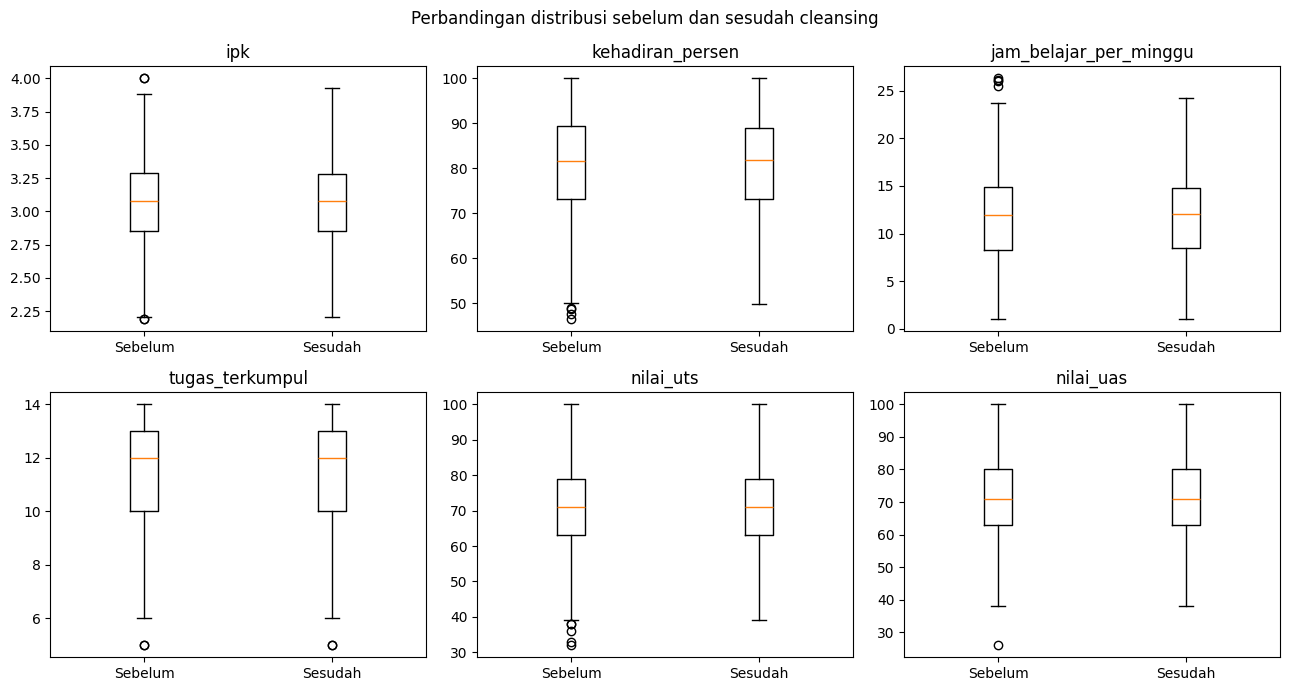

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, c in zip(axes.flat, kolom_num):
    ax.boxplot([df_raw[c].dropna(), df[c]], tick_labels=["Sebelum", "Sesudah"])
    ax.set_title(c)
plt.suptitle("Perbandingan distribusi sebelum dan sesudah cleansing")
plt.tight_layout()
plt.show()

**Kesimpulan:**
- Seluruh missing value (37 sel pada 3 kolom) berhasil ditangani dengan imputasi median per jurusan.
- Outlier dibatasi dengan IQR sehingga rentang data lebih rapat tanpa mengurangi jumlah baris.
- Tidak ada duplikat maupun inkonsistensi format pada dataset ini, sehingga langkah tersebut berfungsi sebagai validasi.
- Data enrichment menambah 8 fitur turunan yang siap dipakai pada tahap analisis atau klasifikasi status kelulusan.

## 7. Simpan Hasil

In [22]:
df.to_csv("dataset_kelulusan_mahasiswa_clean.csv", index=False)
try:
    files.download("dataset_kelulusan_mahasiswa_clean.csv")
except NameError:
    pass

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>